# Regression

### Imports and config

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

KORS_PATH    = Path('../data/original/Forts_IRAF_SAT_Kors _Gemensamt.xlsx')
RAK_PATH     = Path('../data/original/Final_IRAF_SAT_Rak_Bedömare sep och gemensamt.xlsx')
FEATURES_DIR = Path('../data/processed/features')
SELECTED_DIR = FEATURES_DIR / 'combined/per_video'
OUT_DIR      = Path('../data/processed/regression')
OUT_DIR.mkdir(parents=True, exist_ok=True)

PHASE_MAP = {
    'iraf_utg':   'selected_features_utg.csv',
    'iraf_forb':  'selected_features_forb.csv',
    'iraf_uppr':  'selected_features_uppr.csv',
    'iraf_total': 'selected_features_total.csv',
}

## Load IRAF Scores

* Weighted mean over the aspect scores per phase
* Weighted mean over the phase means for the whole movement

In [2]:
def parse_iraf_per_video(xl, sheet_name, phase_map, fp_videos=None):
    _UNSET = object()
    def match_phase(text):
        for prefix, label in phase_map:
            if text.startswith(prefix):
                return label
        return _UNSET

    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].fillna('').astype(str)

    is_block = col0.str.contains('Film Nr', na=False) | col0.str.contains(', [Vv]ideo ', na=False, regex=True)
    if fp_videos is not None:
        is_block = is_block | col0.str.match(r'Fp\d+_', na=False)
    block_rows = raw.index[is_block].tolist()
    block_rows.append(len(raw))

    def get_video(text):
        if 'Film Nr' in text:
            return text.split('Film Nr:')[1].strip().split()[0].zfill(3)
        elif ', video ' in text.lower():
            return text.lower().split(', video ')[1].strip().split()[0].zfill(3)
        elif fp_videos is not None:
            m = re.match(r'Fp(\d+)_', text)
            if m:
                idx = int(m.group(1)) - 1
                return fp_videos[idx] if idx < len(fp_videos) else None
        return None

    records = []
    for i, start in enumerate(block_rows[:-1]):
        video = get_video(col0.iloc[start])
        if video is None:
            continue
        block = raw.iloc[start:block_rows[i+1]]
        current_phase = _UNSET
        for row_idx in block.index:
            cell_text = str(raw.iloc[row_idx, 0]).strip()
            matched = match_phase(cell_text)
            if matched is not _UNSET:
                current_phase = matched
                continue
            if current_phase is _UNSET or current_phase is None:
                continue
            gem = raw.iloc[row_idx, 12]
            weight = pd.to_numeric(raw.iloc[row_idx, 1], errors='coerce')
            if pd.notna(weight) and pd.notna(gem):
                try:
                    records.append({'video': video, 'phase': current_phase,
                                    'weight': weight, 'avvikelse': float(gem)})
                except ValueError:
                    pass
    return pd.DataFrame(records)

UP_PHASE_MAP = [
    ('Utgångsposition',  'utg'),
    ('Rörelsestart',     None),
    ('Rörelseutförande', None),
    ('Förberedelsefas',  'forb'),
    ('Uppresningsfas',   'uppr'),
]

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df = parse_iraf_per_video(kors_xl, 'Sittande till stående', UP_PHASE_MAP)
rak_df  = parse_iraf_per_video(rak_xl,  'Sittande till stående', UP_PHASE_MAP)
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

iraf_pv = iraf_raw.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

phase_score_cols = [c for c in iraf_pv.columns if c != 'video']
iraf_pv['iraf_total'] = iraf_pv[phase_score_cols].mean(axis=1)

iraf_pv

,video,iraf_forb,iraf_uppr,iraf_utg,iraf_total
0,028,0.833333,0.875000,0.870370,0.859568
1,030,0.333333,0.250000,0.055556,0.212963
2,045,1.000000,1.500000,1.407407,1.302469
3,047,0.833333,0.750000,1.523810,1.035714
4,059,0.833333,0.833333,0.937500,0.868056
5,061,0.833333,0.750000,0.650000,0.744444
6,074,0.944444,1.125000,1.047619,1.039021
7,076,0.500000,1.500000,0.555556,0.851852
8,091,0.583333,1.250000,1.460317,1.097884
9,093,0.500000,0.625000,0.722222,0.615741


## Load top correlated features per phase

In [3]:
pose_all = (
    pd.read_csv(FEATURES_DIR / 'utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'förberedelsefas.csv'), on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'uppresningsfas.csv'),  on='video')
)
molab_all = (
    pd.read_csv(FEATURES_DIR / 'molab_utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_förberedelsefas.csv'), on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_uppresningsfas.csv'),  on='video')
)

pose_all['video']  = pose_all['video'].astype(str).str.zfill(3)
molab_all['video'] = molab_all['video'].astype(str).str.zfill(3)
pose_all  = pose_all.rename(columns={c: f'pose_{c}'  for c in pose_all.columns  if c != 'video'})
molab_all = molab_all.rename(columns={c: f'molab_{c}' for c in molab_all.columns if c != 'video'})

iraf = iraf_pv.copy()
iraf['video'] = iraf['video'].astype(str).str[-3:]

phase_dfs = {}
for target, fname in PHASE_MAP.items():
    sel = pd.read_csv(SELECTED_DIR / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature'].tolist()]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature'].tolist()]
    short = target.replace('iraf_', '')
    pose_df  = pose_all[['video'] + pose_feats]
    molab_df = molab_all[['video'] + molab_feats]
    phase_dfs[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        iraf[['video', target]],
    }

for phase, sources in phase_dfs.items():
    print(f"\n{phase}:")
    for source, val in sources.items():
        if source == 'y':
            scores = val.iloc[:, 1].round(2).tolist()
            print(f"  y: {scores}")
        else:
            print(f"  {source}: {val.shape} {val.columns[1:].tolist()}")


utg:
  pose: (10, 4) ['pose_forb_mean_trunk_angular_velocity', 'pose_uppr_trunk_hip_correlation', 'pose_uppr_hip_forward_displacement']
  molab: (10, 4) ['molab_utg_mean_R_knee_flexion', 'molab_forb_peak_pelvis_gyro', 'molab_forb_mean_pelvis_gyro']
  combined: (10, 7) ['pose_forb_mean_trunk_angular_velocity', 'pose_uppr_trunk_hip_correlation', 'pose_uppr_hip_forward_displacement', 'molab_utg_mean_R_knee_flexion', 'molab_forb_peak_pelvis_gyro', 'molab_forb_mean_pelvis_gyro']
  y: [0.87, 0.06, 1.41, 1.52, 0.94, 0.65, 1.05, 0.56, 1.46, 0.72]

forb:
  pose: (10, 4) ['pose_uppr_hip_forward_displacement', 'pose_uppr_trunk_hip_correlation', 'pose_uppr_trunk_reextension_angle']
  molab: (10, 4) ['molab_uppr_total_hip_extension', 'molab_uppr_total_knee_extension', 'molab_forb_peak_pelvis_gyro']
  combined: (10, 7) ['pose_uppr_hip_forward_displacement', 'pose_uppr_trunk_hip_correlation', 'pose_uppr_trunk_reextension_angle', 'molab_uppr_total_hip_extension', 'molab_uppr_total_knee_extension', 'm

## Regression: LOOCV

In [4]:
MODELS = {
    'Linear':       LinearRegression(),
    'Ridge':        Ridge(),
    'RandomForest': RandomForestRegressor(max_depth=3, n_estimators=50, random_state=42),
}

FEATURE_SETS = ['pose', 'molab', 'combined']
MODEL_ORDER  = ['Linear', 'Ridge', 'RandomForest']

loo = LeaveOneOut()
loocv_results = []

for phase, data in phase_dfs.items():
    y = data['y'].iloc[:, 1].values
    for fs in FEATURE_SETS:
        X = data[fs].drop(columns='video').values
        feature_names = data[fs].drop(columns='video').columns.tolist()
        for model_name, model in MODELS.items():
            preds = np.empty(len(y))
            importances = []
            for train_idx, test_idx in loo.split(X):
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X[train_idx])
                X_test  = scaler.transform(X[test_idx])
                m = clone(model)
                m.fit(X_train, y[train_idx])
                preds[test_idx] = m.predict(X_test)
                if model_name == 'RandomForest':
                    importances.append(m.feature_importances_)
            entry = {
                'phase':       phase,
                'feature_set': fs,
                'model':       model_name,
                'y_true':      y.copy(),
                'y_pred':      preds,
            }
            if model_name == 'RandomForest':
                entry['feature_names']        = feature_names
                entry['mean_importances'] = np.mean(importances, axis=0)
            loocv_results.append(entry)

print(f"{len(loocv_results)} models trained ({len(phase_dfs)} phases x {len(FEATURE_SETS)} feature sets x {len(MODELS)} models)")

36 models trained (4 phases x 3 feature sets x 3 models)


## Evaluation

In [5]:
rows = []
for r in loocv_results:
    mae  = mean_absolute_error(r['y_true'], r['y_pred'])
    rmse = np.sqrt(mean_squared_error(r['y_true'], r['y_pred']))
    r2   = r2_score(r['y_true'], r['y_pred'])
    rows.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'MAE':         mae,
        'RMSE':        rmse,
        'R2':          r2,
    })

eval_df = pd.DataFrame(rows)

for phase in eval_df['phase'].unique():
    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    for metric in ['MAE', 'RMSE', 'R2']:
        pivot = eval_df[eval_df['phase'] == phase].pivot(
            index='model', columns='feature_set', values=metric
        ).loc[MODEL_ORDER, ['pose', 'molab', 'combined']]
        print(f"\n{metric}:")
        print(pivot.round(3).to_string())


Phase: utg

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.407  0.313     0.753
Ridge         0.379  0.239     0.310
RandomForest  0.293  0.246     0.244

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.523  0.405     0.947
Ridge         0.499  0.327     0.386
RandomForest  0.388  0.378     0.377

R2:
feature_set    pose  molab  combined
model                               
Linear       -0.436  0.141    -3.703
Ridge        -0.305  0.439     0.217
RandomForest  0.209  0.248     0.254

Phase: forb

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.244  0.154     0.489
Ridge         0.231  0.144     0.200
RandomForest  0.282  0.159     0.169

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.283  0.181     0.592
Ridge         0.251  0.172     0.226
RandomForest  0.291  0.193     0.201

R2:
feature_set   

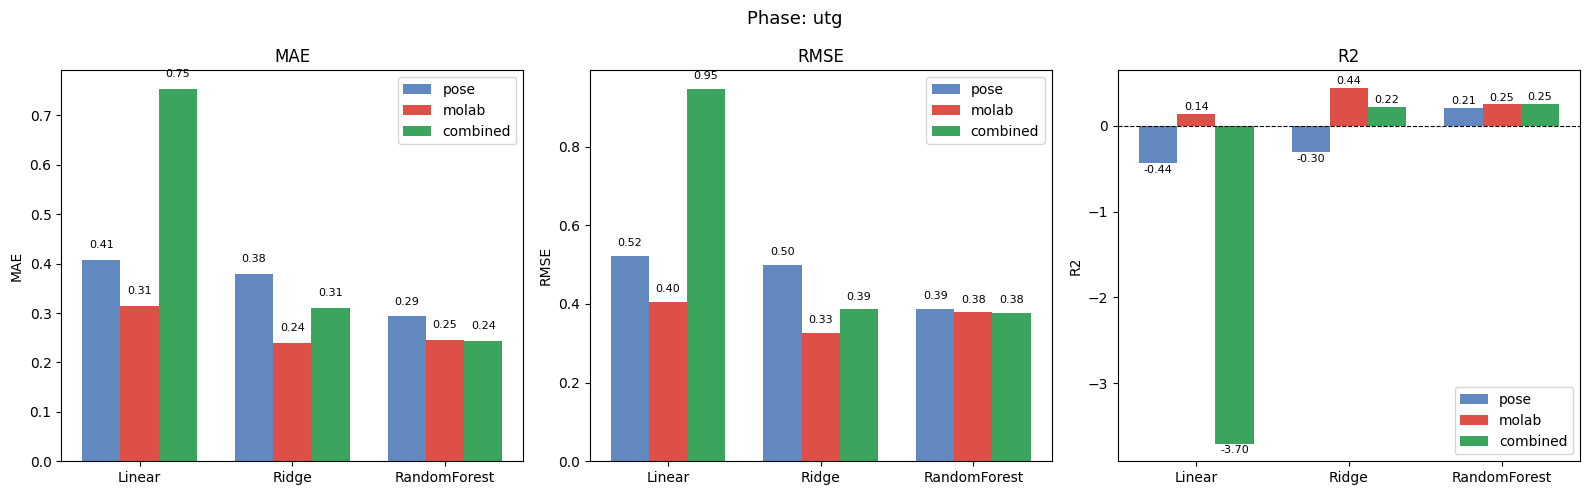

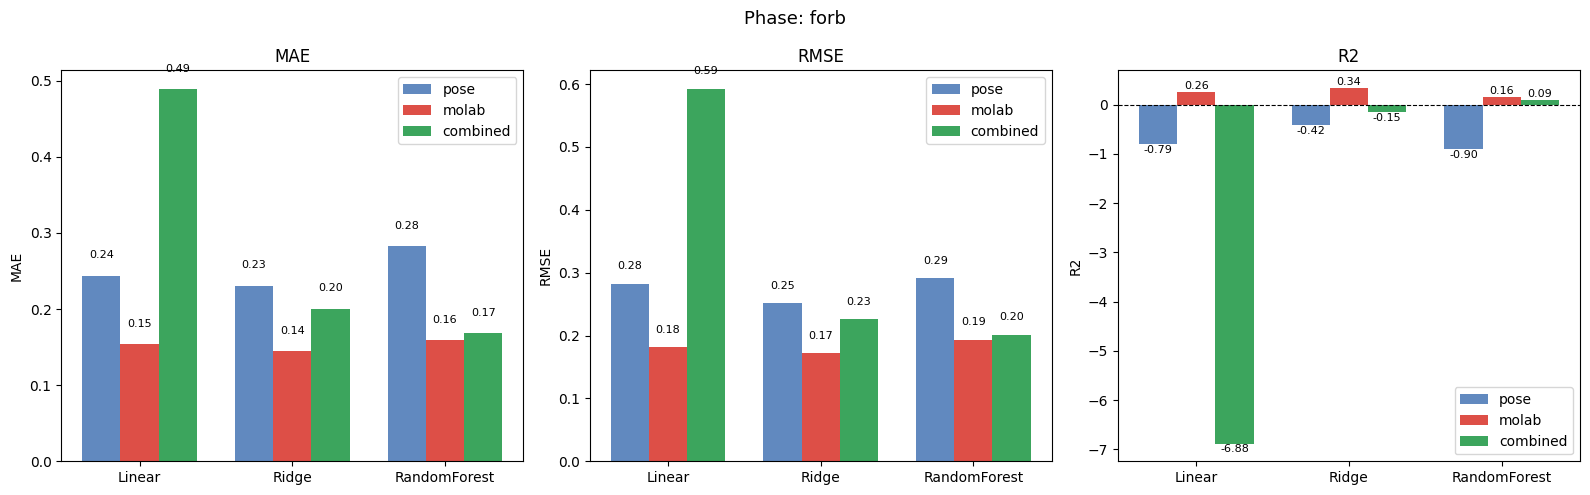

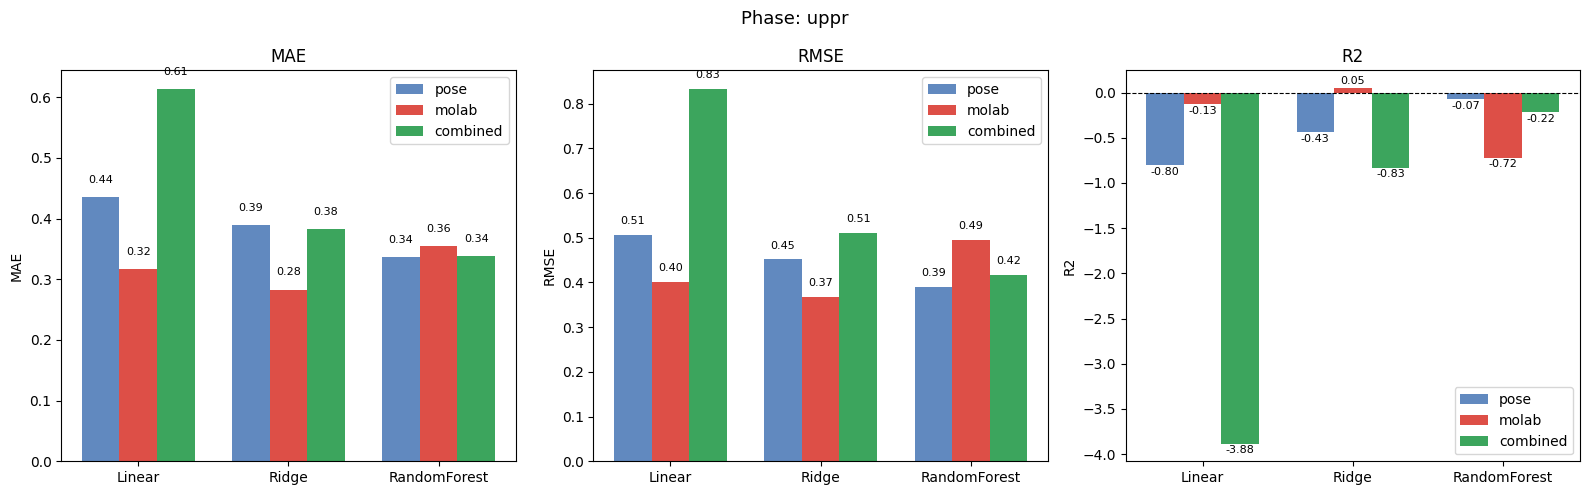

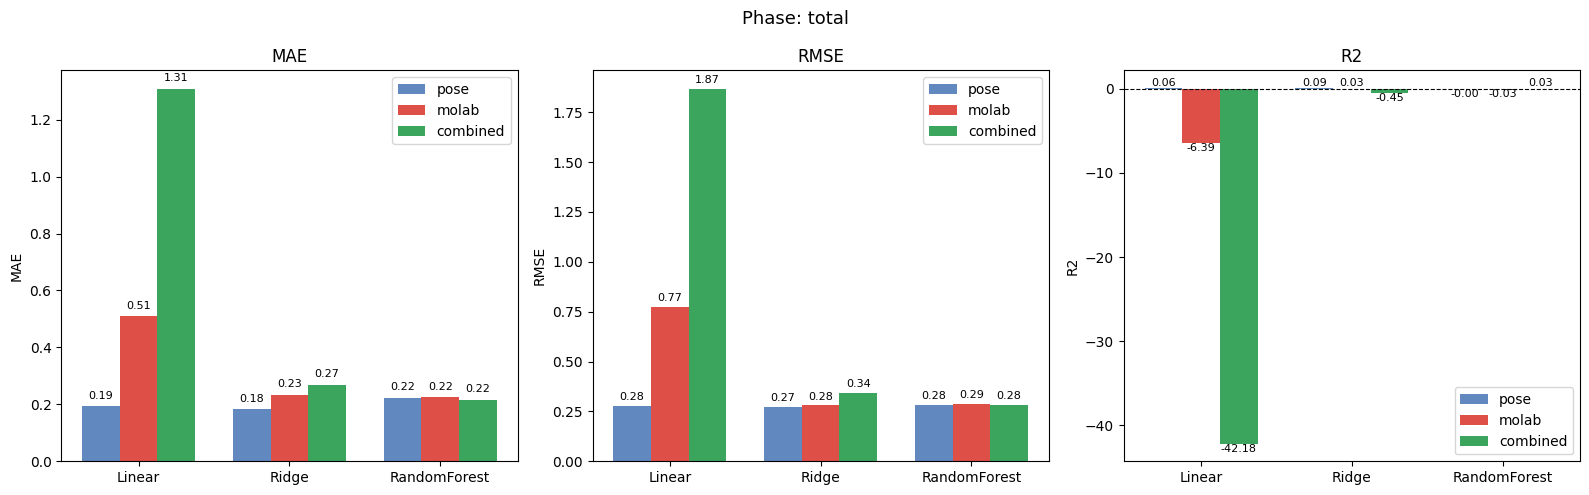

In [6]:
METRICS      = ['MAE', 'RMSE', 'R2']
COLORS       = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}

x = np.arange(len(MODEL_ORDER))
width = 0.25

for phase in eval_df['phase'].unique():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Phase: {phase}', fontsize=13)

    for ax, metric in zip(axes, METRICS):
        sub = eval_df[eval_df['phase'] == phase]
        for i, fs in enumerate(FEATURE_SETS):
            vals = [sub[(sub['model'] == m) & (sub['feature_set'] == fs)][metric].values[0]
                    for m in MODEL_ORDER]
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS[fs], alpha=0.85)
            for bar, val in zip(bars, vals):
                y_pos = bar.get_height() + (0.02 if val >= 0 else -0.02)
                va = 'bottom' if val >= 0 else 'top'
                ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                        f'{val:.2f}', ha='center', va=va, fontsize=8)

        ax.set_title(metric)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER)
        ax.set_ylabel(metric)
        if metric == 'R2':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'regression_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

## ANOVA: prediction errors across feature sets

In [7]:
anova_rows = []

for phase in eval_df['phase'].unique():
    for model in MODEL_ORDER:
        errors = {}
        for fs in FEATURE_SETS:
            r = next(x for x in loocv_results
                     if x['phase'] == phase and x['model'] == model and x['feature_set'] == fs)
            errors[fs] = np.abs(r['y_true'] - r['y_pred'])

        f_stat, p_val = f_oneway(errors['pose'], errors['molab'], errors['combined'])
        anova_rows.append({
            'phase': phase, 'model': model,
            'F': round(f_stat, 3), 'p': round(p_val, 3),
            'significant': p_val < 0.05,
        })

anova_df = pd.DataFrame(anova_rows)
anova_df

,phase,model,F,p,significant
0,utg,Linear,2.890,0.073,False
1,utg,Ridge,0.630,0.540,False
2,utg,RandomForest,0.091,0.913,False
3,forb,Linear,5.770,0.008,True
4,forb,Ridge,1.768,0.190,False
5,forb,RandomForest,4.402,0.022,True
6,uppr,Linear,1.367,0.272,False
7,uppr,Ridge,0.439,0.649,False
8,uppr,RandomForest,0.013,0.988,False
9,total,Linear,4.148,0.027,True


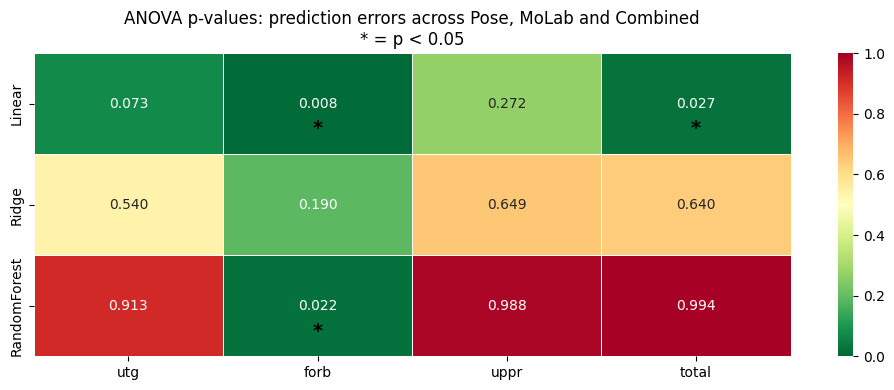

In [8]:
PHASE_ORDER = ['utg', 'forb', 'uppr', 'total']

pivot_p = anova_df.pivot(index='model', columns='phase', values='p')
pivot_p = pivot_p.loc[MODEL_ORDER, PHASE_ORDER]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_p, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 10})
for i, model in enumerate(pivot_p.index):
    for j, phase in enumerate(pivot_p.columns):
        if pivot_p.loc[model, phase] < 0.05:
            ax.text(j + 0.5, i + 0.75, '*', ha='center', va='center', fontsize=14, fontweight='bold')

ax.set_title('ANOVA p-values: prediction errors across Pose, MoLab and Combined\n* = p < 0.05', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT_DIR / 'anova_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (Random Forest)

In [9]:
for phase in PHASE_ORDER:
    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    for fs in FEATURE_SETS:
        r = next(x for x in loocv_results
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        df = pd.DataFrame({
            'feature':    r['feature_names'],
            'importance': r['mean_importances'],
        }).sort_values('importance', ascending=False).reset_index(drop=True)
        print(f"\n{fs}:")
        print(df.round(4).to_string(index=False))


Phase: utg

pose:
                              feature  importance
pose_forb_mean_trunk_angular_velocity      0.5962
   pose_uppr_hip_forward_displacement      0.2461
      pose_uppr_trunk_hip_correlation      0.1577

molab:
                      feature  importance
molab_utg_mean_R_knee_flexion      0.4397
  molab_forb_mean_pelvis_gyro      0.2907
  molab_forb_peak_pelvis_gyro      0.2696

combined:
                              feature  importance
pose_forb_mean_trunk_angular_velocity      0.2861
        molab_utg_mean_R_knee_flexion      0.2748
          molab_forb_peak_pelvis_gyro      0.1805
          molab_forb_mean_pelvis_gyro      0.0999
   pose_uppr_hip_forward_displacement      0.0893
      pose_uppr_trunk_hip_correlation      0.0694

Phase: forb

pose:
                           feature  importance
   pose_uppr_trunk_hip_correlation      0.3637
pose_uppr_hip_forward_displacement      0.3614
 pose_uppr_trunk_reextension_angle      0.2749

molab:
                        feat

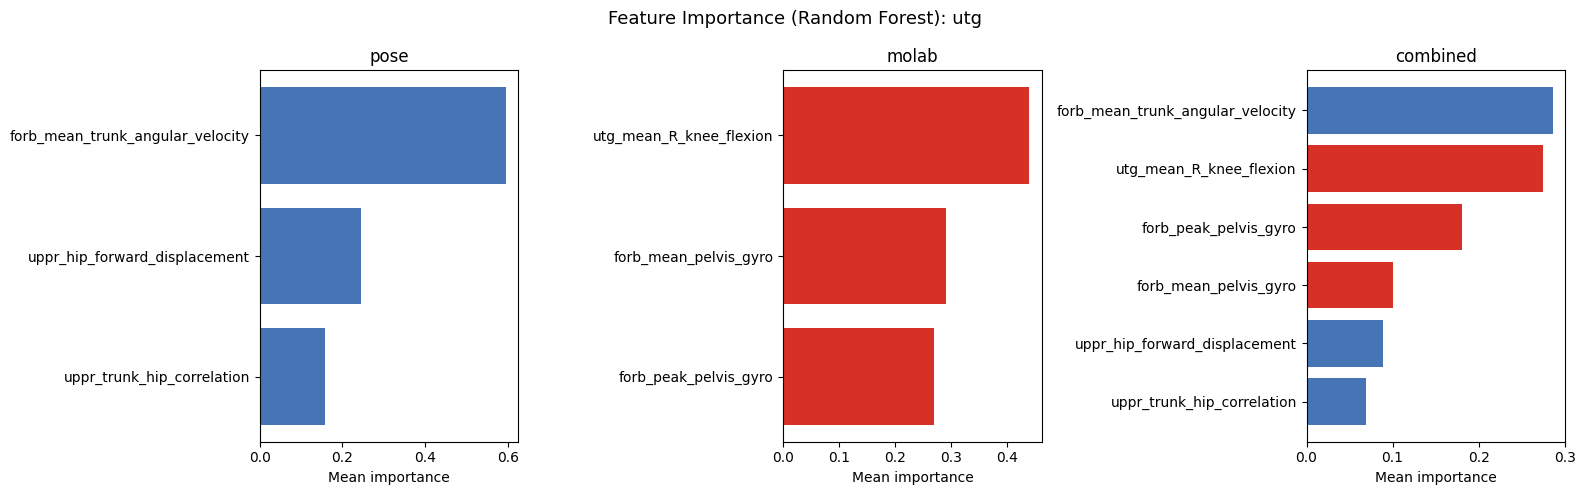

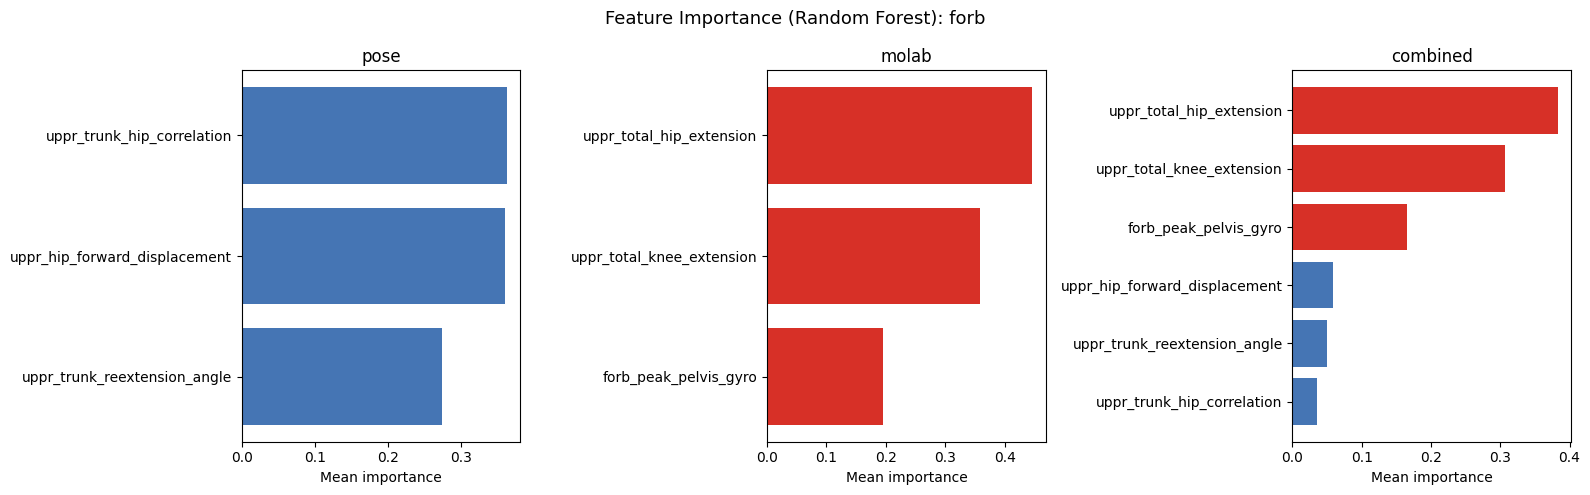

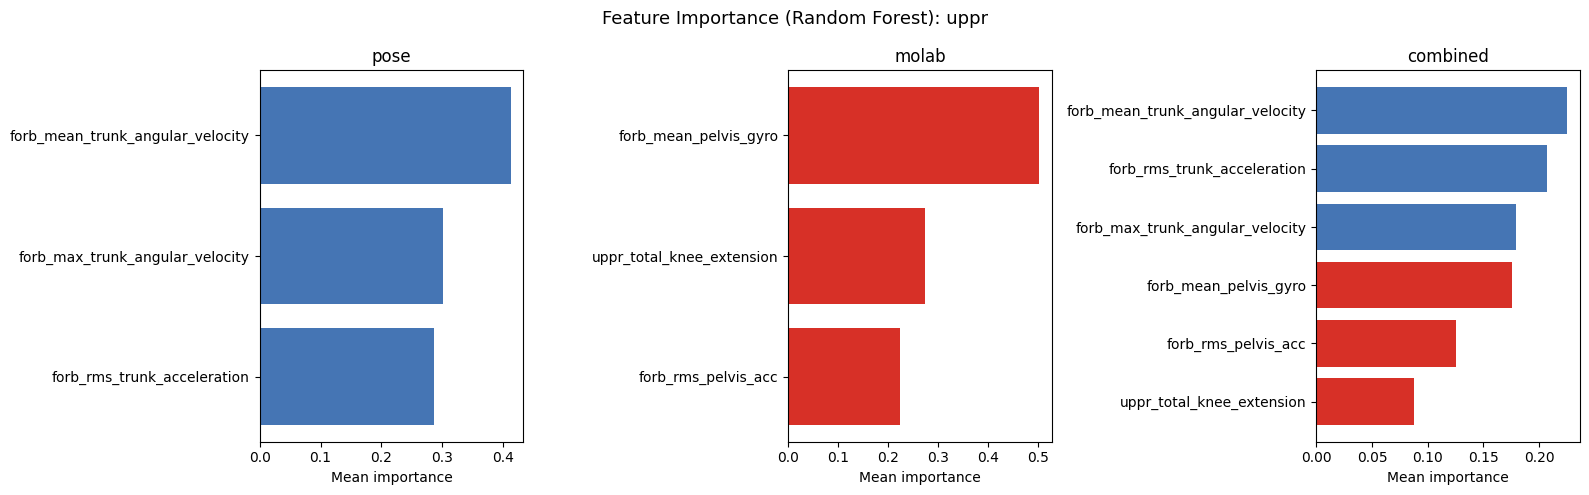

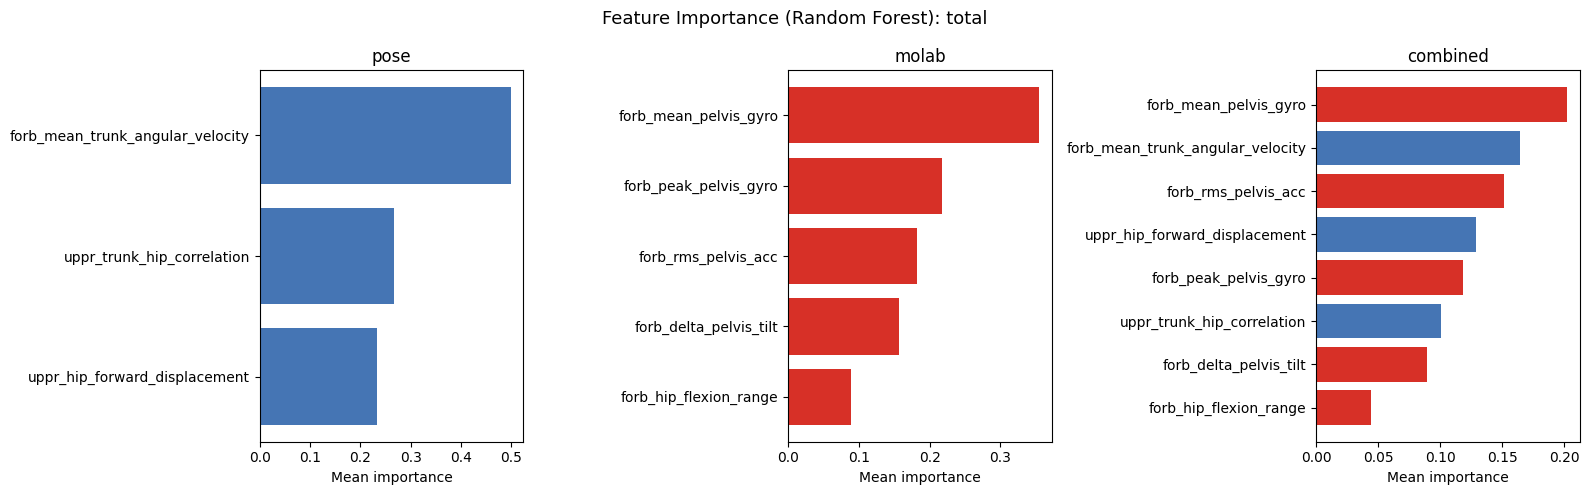

In [10]:
PHASE_ORDER = ['utg', 'forb', 'uppr', 'total']

for phase in PHASE_ORDER:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Feature Importance (Random Forest): {phase}', fontsize=13)

    for ax, fs in zip(axes, FEATURE_SETS):
        r = next(x for x in loocv_results
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        names = [n.replace('pose_', '').replace('molab_', '') for n in r['feature_names']]
        imps  = r['mean_importances']
        order = np.argsort(imps)
        colors = ['#d73027' if 'molab_' in r['feature_names'][i] else '#4575b4' for i in order]
        ax.barh([names[i] for i in order], imps[order], color=colors)
        ax.set_title(fs)
        ax.set_xlabel('Mean importance')

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'feature_importance_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Error Analysis (Random Forest): Pose vs MoLab per video

In [11]:
videos = phase_dfs['utg']['y']['video'].tolist()

for phase in PHASE_ORDER:
    pose_r  = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    df = pd.DataFrame({
        'video':       videos,
        'pose_error':  np.abs(pose_r['y_true']  - pose_r['y_pred']),
        'molab_error': np.abs(molab_r['y_true'] - molab_r['y_pred']),
    })
    df['better'] = df.apply(lambda row: 'Pose' if row['pose_error'] < row['molab_error'] else 'MoLab', axis=1)

    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    print(df.round(4).to_string(index=False))


Phase: utg
video  pose_error  molab_error better
  028      0.2399       0.2566   Pose
  030      0.6759       0.7661   Pose
  045      0.0548       0.0878   Pose
  047      0.8762       0.8367  MoLab
  059      0.2720       0.1742  MoLab
  061      0.2068       0.0267  MoLab
  074      0.1756       0.0714  MoLab
  076      0.2293       0.0047  MoLab
  091      0.1257       0.1777   Pose
  093      0.0753       0.0598  MoLab

Phase: forb
video  pose_error  molab_error better
  028      0.2372       0.1483  MoLab
  030      0.4154       0.3133  MoLab
  045      0.2497       0.2117  MoLab
  047      0.3556       0.3161  MoLab
  059      0.2853       0.0233  MoLab
  061      0.2933       0.0472  MoLab
  074      0.1558       0.0661  MoLab
  076      0.2367       0.1683  MoLab
  091      0.3400       0.2678  MoLab
  093      0.2558       0.0283  MoLab

Phase: uppr
video  pose_error  molab_error better
  028      0.3138       0.2976  MoLab
  030      0.6631       1.0408   Pose
  045      0

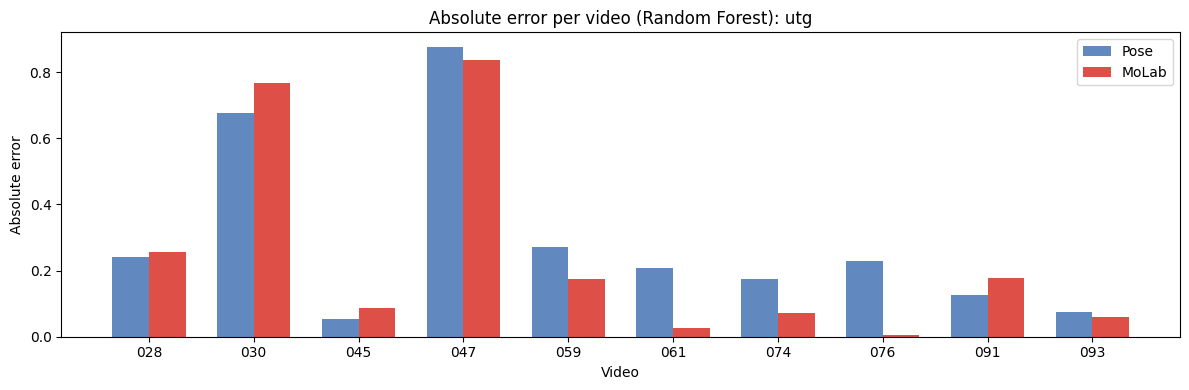

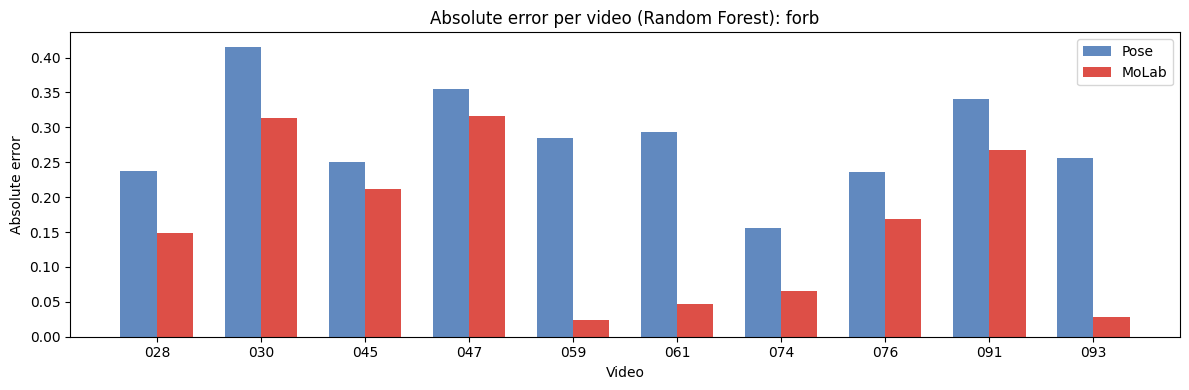

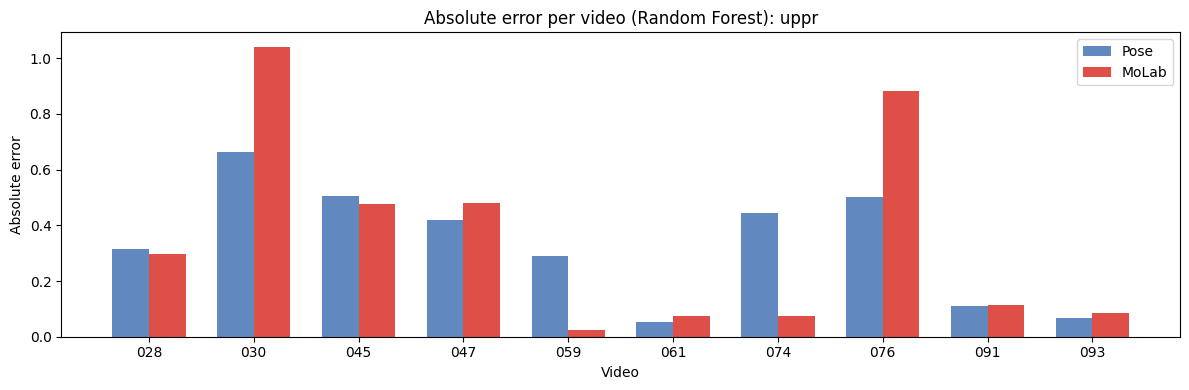

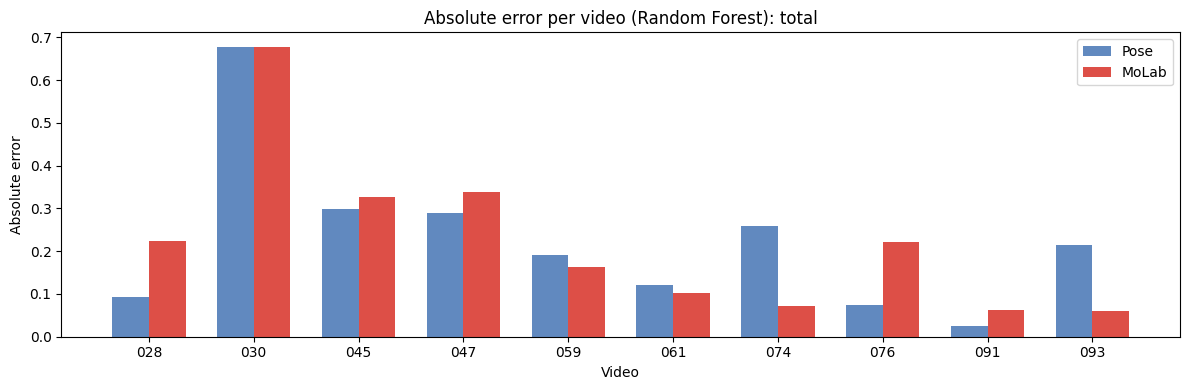

In [12]:
videos = phase_dfs['utg']['y']['video'].tolist()

x = np.arange(len(videos))
width = 0.35

for phase in PHASE_ORDER:
    pose_r  = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    pose_errors  = np.abs(pose_r['y_true']  - pose_r['y_pred'])
    molab_errors = np.abs(molab_r['y_true'] - molab_r['y_pred'])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - width/2, pose_errors,  width, label='Pose',  color='#4575b4', alpha=0.85)
    ax.bar(x + width/2, molab_errors, width, label='MoLab', color='#d73027', alpha=0.85)

    ax.set_title(f'Absolute error per video (Random Forest): {phase}')
    ax.set_xticks(x)
    ax.set_xticklabels(videos)
    ax.set_xlabel('Video')
    ax.set_ylabel('Absolute error')
    ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'error_analysis_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Stående till sittande (Stand-to-Sit)

In [13]:
OUT_DIR_DOWN = Path('../data/processed/regression_down')
OUT_DIR_DOWN.mkdir(parents=True, exist_ok=True)

DOWN_FEATURES_DIR = Path('../data/processed/features_down')
DOWN_SELECTED_DIR = DOWN_FEATURES_DIR / 'combined/per_video'

DOWN_PHASE_MAP = [
    ('Utgångsposition',  'utg'),
    ('Rörelsestart',     None),
    ('Rörelseutförande', None),
    ('Fas 1',            'ned'),
    ('Fas 2',            'bak'),
]

PHASE_MAP_DOWN = {
    'iraf_utg':   'selected_features_utg.csv',
    'iraf_ned':   'selected_features_ned.csv',
    'iraf_bak':   'selected_features_bak.csv',
    'iraf_total': 'selected_features_total.csv',
}

RAK_DOWN_FP_VIDEOS = ['030', '047', '061', '076', '093']

kors_df_d = parse_iraf_per_video(kors_xl, 'Stående till sittande', DOWN_PHASE_MAP)
rak_df_d  = parse_iraf_per_video(rak_xl,  'Stående till sittande', DOWN_PHASE_MAP, fp_videos=RAK_DOWN_FP_VIDEOS)
iraf_raw_d = pd.concat([kors_df_d, rak_df_d], ignore_index=True)
iraf_raw_d = iraf_raw_d.assign(w=iraf_raw_d['avvikelse'] * iraf_raw_d['weight'])

iraf_pv_d = iraf_raw_d.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv_d.columns.name = None
iraf_pv_d.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv_d.columns[1:]]

phase_score_cols_d = [c for c in iraf_pv_d.columns if c != 'video']
iraf_pv_d['iraf_total'] = iraf_pv_d[phase_score_cols_d].mean(axis=1)

iraf_pv_d

,video,iraf_bak,iraf_ned,iraf_utg,iraf_total
0,028,2.000000,0.000000,0.428571,0.809524
1,030,0.000000,0.000000,0.000000,0.000000
2,045,1.866667,0.363636,1.125000,1.118434
3,047,0.714286,0.454545,0.600000,0.589610
4,059,1.333333,0.083333,0.666667,0.694444
5,061,0.600000,0.375000,0.733333,0.569444
6,074,1.466667,0.208333,0.444444,0.706481
7,076,0.600000,0.375000,1.133333,0.702778
8,091,1.333333,0.208333,0.555556,0.699074
9,093,1.000000,0.727273,1.000000,0.909091


In [14]:
pose_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR / 'down_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR / 'down_nedåtgående.csv'),  on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR / 'down_bakåtgående.csv'),  on='video')
)
molab_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR / 'down_molab_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR / 'down_molab_nedåtgående.csv'),  on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR / 'down_molab_bakåtgående.csv'),  on='video')
)

pose_all_d['video']  = pose_all_d['video'].astype(str).str.zfill(3)
molab_all_d['video'] = molab_all_d['video'].astype(str).str.zfill(3)
pose_all_d  = pose_all_d.rename(columns={c: f'pose_{c}'  for c in pose_all_d.columns  if c != 'video'})
molab_all_d = molab_all_d.rename(columns={c: f'molab_{c}' for c in molab_all_d.columns if c != 'video'})

iraf_d = iraf_pv_d.copy()
iraf_d['video'] = iraf_d['video'].astype(str).str[-3:]

phase_dfs_down = {}
for target, fname in PHASE_MAP_DOWN.items():
    sel = pd.read_csv(DOWN_SELECTED_DIR / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature'].tolist()]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature'].tolist()]
    short = target.replace('iraf_', '')
    pose_df  = pose_all_d[['video'] + pose_feats]
    molab_df = molab_all_d[['video'] + molab_feats]
    phase_dfs_down[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        iraf_d[['video', target]],
    }

for phase, sources in phase_dfs_down.items():
    print(f"\n{phase}:")
    for source, val in sources.items():
        if source == 'y':
            scores = val.iloc[:, 1].round(2).tolist()
            print(f"  y: {scores}")
        else:
            print(f"  {source}: {val.shape} {val.columns[1:].tolist()}")


utg:
  pose: (10, 4) ['pose_utg_stance_to_hip_ratio', 'pose_utg_stance_width', 'pose_ned_peak_pelvis_velocity_y']
  molab: (10, 4) ['molab_ned_peak_thigh_gyro', 'molab_ned_pelvis_lateral', 'molab_bak_delta_pelvis_tilt']
  combined: (10, 7) ['pose_utg_stance_to_hip_ratio', 'pose_utg_stance_width', 'pose_ned_peak_pelvis_velocity_y', 'molab_ned_peak_thigh_gyro', 'molab_ned_pelvis_lateral', 'molab_bak_delta_pelvis_tilt']
  y: [0.43, 0.0, 1.12, 0.6, 0.67, 0.73, 0.44, 1.13, 0.56, 1.0]

ned:
  pose: (10, 4) ['pose_ned_peak_trunk_angular_velocity', 'pose_ned_rms_trunk_acceleration', 'pose_utg_mean_trunk_angle']
  molab: (10, 4) ['molab_utg_delta_knee_asymmetry', 'molab_bak_pelvis_lateral', 'molab_ned_pelvis_lateral']
  combined: (10, 7) ['pose_ned_peak_trunk_angular_velocity', 'pose_ned_rms_trunk_acceleration', 'pose_utg_mean_trunk_angle', 'molab_utg_delta_knee_asymmetry', 'molab_bak_pelvis_lateral', 'molab_ned_pelvis_lateral']
  y: [0.0, 0.0, 0.36, 0.45, 0.08, 0.38, 0.21, 0.38, 0.21, 0.73]



In [15]:
loocv_results_down = []

for phase, data in phase_dfs_down.items():
    y = data['y'].iloc[:, 1].values
    for fs in FEATURE_SETS:
        X = data[fs].drop(columns='video').values
        feature_names = data[fs].drop(columns='video').columns.tolist()
        for model_name, model in MODELS.items():
            preds = np.empty(len(y))
            importances = []
            for train_idx, test_idx in loo.split(X):
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X[train_idx])
                X_test  = scaler.transform(X[test_idx])
                m = clone(model)
                m.fit(X_train, y[train_idx])
                preds[test_idx] = m.predict(X_test)
                if model_name == 'RandomForest':
                    importances.append(m.feature_importances_)
            entry = {
                'phase':       phase,
                'feature_set': fs,
                'model':       model_name,
                'y_true':      y.copy(),
                'y_pred':      preds,
            }
            if model_name == 'RandomForest':
                entry['feature_names']    = feature_names
                entry['mean_importances'] = np.mean(importances, axis=0)
            loocv_results_down.append(entry)

print(f"{len(loocv_results_down)} models trained")


36 models trained


In [16]:
rows_d = []
for r in loocv_results_down:
    yt, yp = r['y_true'], r['y_pred']
    rows_d.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'MAE':         mean_absolute_error(yt, yp),
        'RMSE':        np.sqrt(mean_squared_error(yt, yp)),
        'R2':          r2_score(yt, yp),
    })

eval_df_down = pd.DataFrame(rows_d)

for phase in eval_df_down['phase'].unique():
    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    for metric in ['MAE', 'RMSE', 'R2']:
        pivot = eval_df_down[eval_df_down['phase'] == phase].pivot(
            index='model', columns='feature_set', values=metric
        ).loc[MODEL_ORDER, ['pose', 'molab', 'combined']]
        print(f"\n{metric}:")
        print(pivot.round(3).to_string())



Phase: utg

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.355  0.376     0.696
Ridge         0.295  0.339     0.357
RandomForest  0.304  0.285     0.263

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.452  0.505     0.799
Ridge         0.373  0.460     0.449
RandomForest  0.398  0.352     0.340

R2:
feature_set    pose  molab  combined
model                               
Linear       -0.838 -1.297    -4.753
Ridge        -0.252 -0.906    -0.819
RandomForest -0.429 -0.116    -0.043

Phase: ned

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.228  0.151     0.183
Ridge         0.203  0.130     0.122
RandomForest  0.163  0.153     0.131

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.274  0.169     0.204
Ridge         0.243  0.158     0.144
RandomForest  0.205  0.185     0.164

R2:
feature_set    

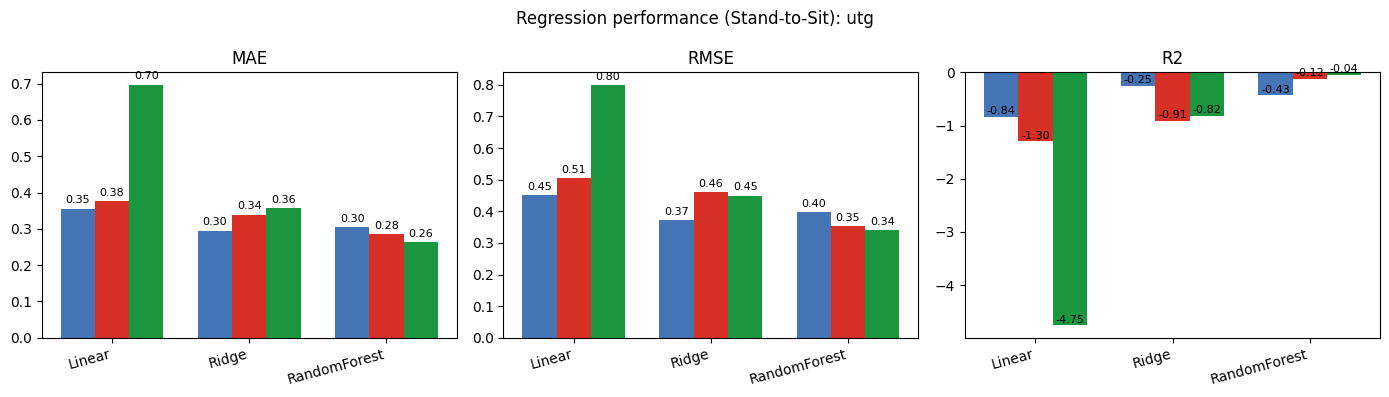

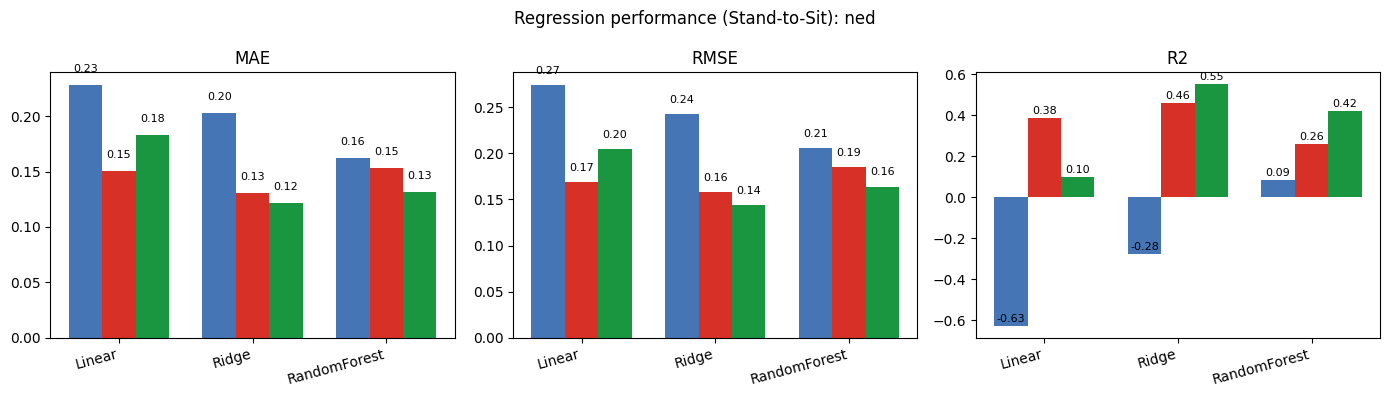

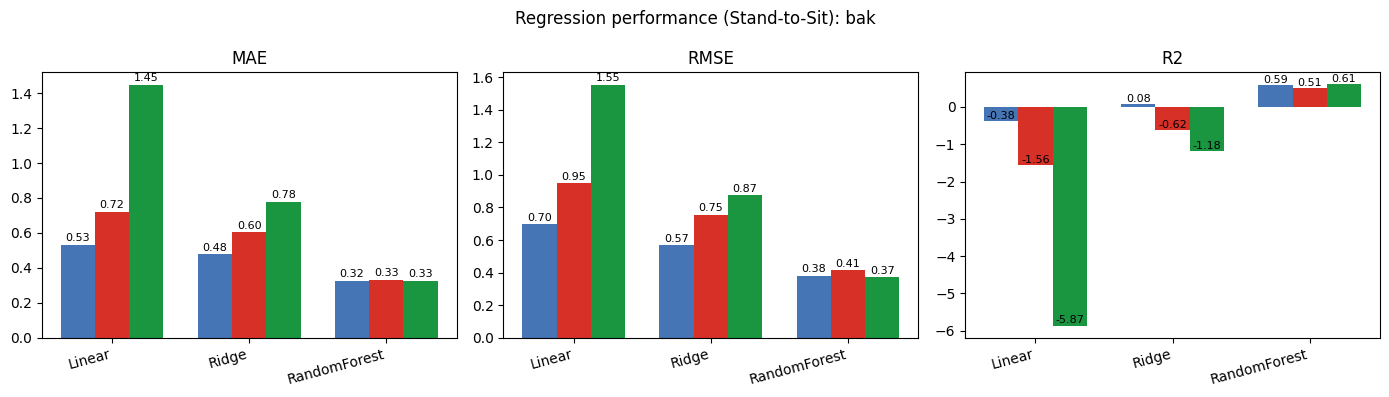

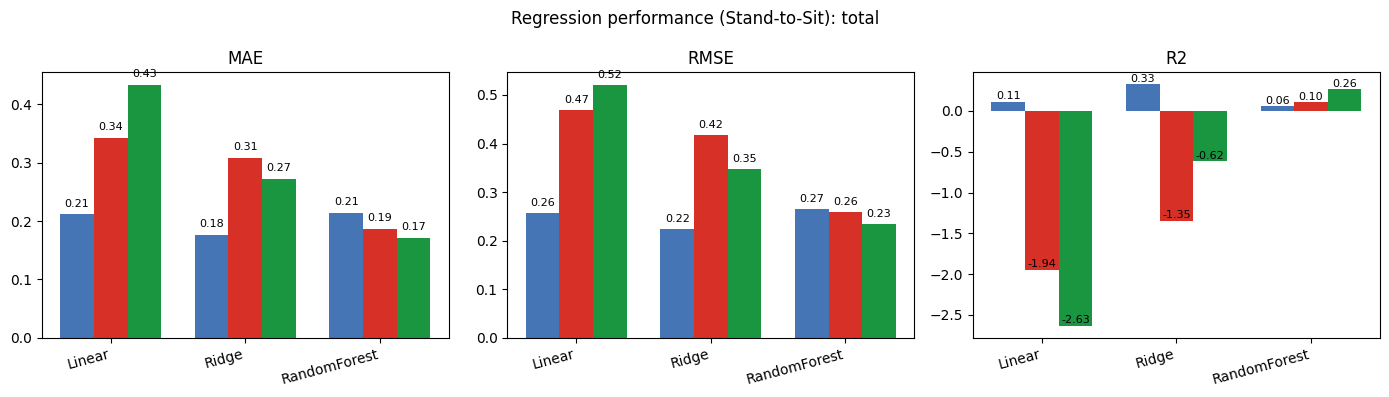

In [17]:
PHASE_ORDER_DOWN = list(phase_dfs_down.keys())
COLORS_FS = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}

for phase in PHASE_ORDER_DOWN:
    sub = eval_df_down[eval_df_down['phase'] == phase]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
        x = np.arange(len(MODEL_ORDER))
        width = 0.25
        for i, fs in enumerate(FEATURE_SETS):
            vals = [sub[(sub['model'] == m) & (sub['feature_set'] == fs)][metric].values[0]
                    for m in MODEL_ORDER]
            bars = ax.bar(x + i*width, vals, width, label=fs, color=COLORS_FS[fs])
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        ax.set_title(metric)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
        if i == 0:
            ax.legend()
    fig.suptitle(f'Regression performance (Stand-to-Sit): {phase}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN / f'regression_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [18]:
anova_rows_d = []

for phase in PHASE_ORDER_DOWN:
    for model_name in MODEL_ORDER:
        errors = {}
        for fs in FEATURE_SETS:
            r = next(x for x in loocv_results_down
                     if x['phase'] == phase and x['model'] == model_name and x['feature_set'] == fs)
            errors[fs] = np.abs(r['y_true'] - r['y_pred'])
        f_stat, p_val = f_oneway(errors['pose'], errors['molab'], errors['combined'])
        anova_rows_d.append({
            'phase': phase, 'model': model_name,
            'F': round(f_stat, 3), 'p': round(p_val, 3),
            'significant': p_val < 0.05,
        })

anova_df_down = pd.DataFrame(anova_rows_d)
anova_df_down


,phase,model,F,p,significant
0,utg,Linear,2.854,0.075,False
1,utg,Ridge,0.121,0.886,False
2,utg,RandomForest,0.074,0.929,False
3,ned,Linear,1.110,0.344,False
4,ned,Ridge,1.705,0.201,False
5,ned,RandomForest,0.190,0.828,False
6,bak,Linear,7.021,0.004,True
7,bak,Ridge,1.330,0.281,False
8,bak,RandomForest,0.003,0.997,False
9,total,Linear,1.626,0.215,False


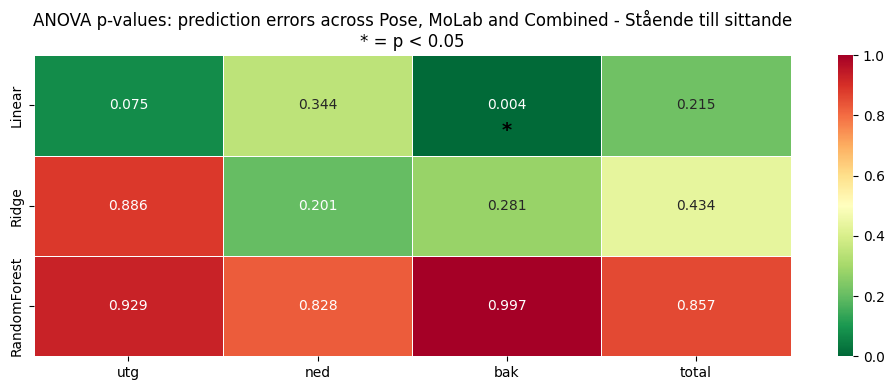

In [19]:
pivot_p_d = anova_df_down.pivot(index='model', columns='phase', values='p')
pivot_p_d = pivot_p_d.loc[MODEL_ORDER, PHASE_ORDER_DOWN]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_p_d, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 10})
for i, model in enumerate(pivot_p_d.index):
    for j, phase in enumerate(pivot_p_d.columns):
        if pivot_p_d.loc[model, phase] < 0.05:
            ax.text(j + 0.5, i + 0.75, '*', ha='center', va='center', fontsize=14, fontweight='bold')

ax.set_title('ANOVA p-values: prediction errors across Pose, MoLab and Combined - St\u00e5ende till sittande\n* = p < 0.05', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT_DIR_DOWN / 'anova_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
for phase in PHASE_ORDER_DOWN:
    for fs in FEATURE_SETS:
        r = next(x for x in loocv_results_down
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        imp_df = pd.DataFrame({'feature': r['feature_names'], 'importance': r['mean_importances']})
        imp_df = imp_df.sort_values('importance', ascending=False)
        print(f"\n{phase} | {fs}")
        print(imp_df.round(4).to_string(index=False))



utg | pose
                        feature  importance
          pose_utg_stance_width      0.3617
pose_ned_peak_pelvis_velocity_y      0.3240
   pose_utg_stance_to_hip_ratio      0.3144

utg | molab
                    feature  importance
   molab_ned_pelvis_lateral      0.4841
molab_bak_delta_pelvis_tilt      0.2690
  molab_ned_peak_thigh_gyro      0.2469

utg | combined
                        feature  importance
       molab_ned_pelvis_lateral      0.3307
          pose_utg_stance_width      0.1926
    molab_bak_delta_pelvis_tilt      0.1421
   pose_utg_stance_to_hip_ratio      0.1174
      molab_ned_peak_thigh_gyro      0.1087
pose_ned_peak_pelvis_velocity_y      0.1085

ned | pose
                             feature  importance
           pose_utg_mean_trunk_angle      0.3775
pose_ned_peak_trunk_angular_velocity      0.3644
     pose_ned_rms_trunk_acceleration      0.2581

ned | molab
                       feature  importance
molab_utg_delta_knee_asymmetry      0.4857
      mo

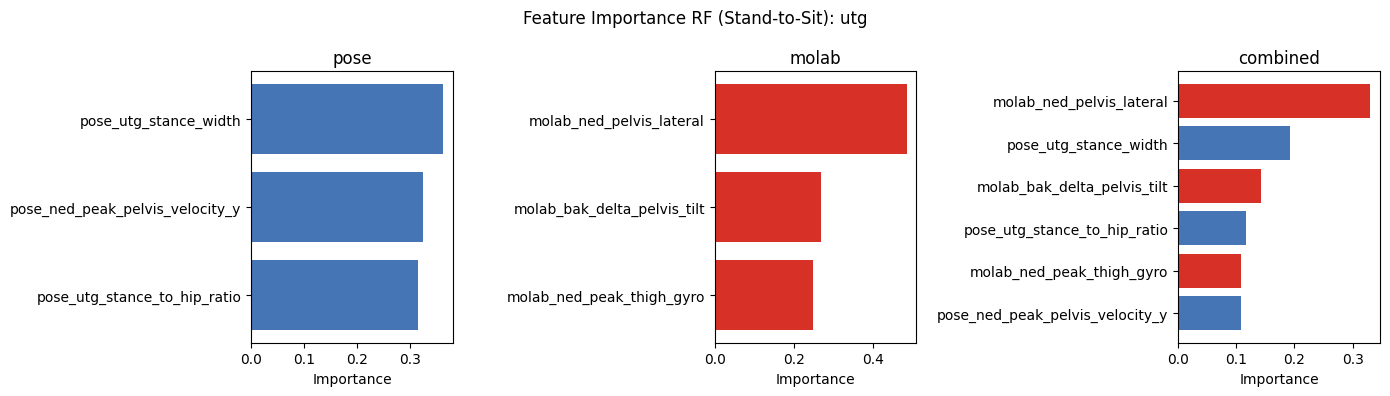

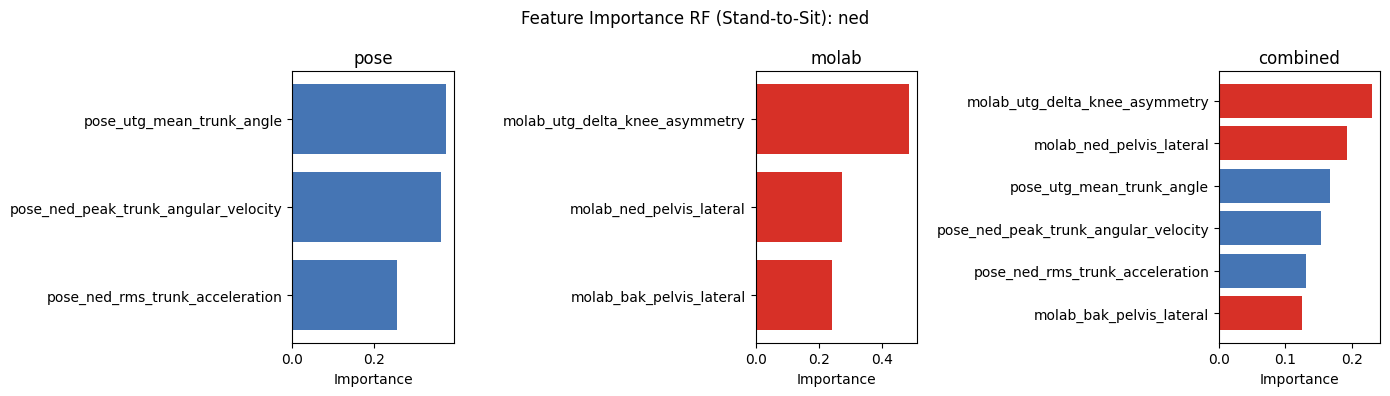

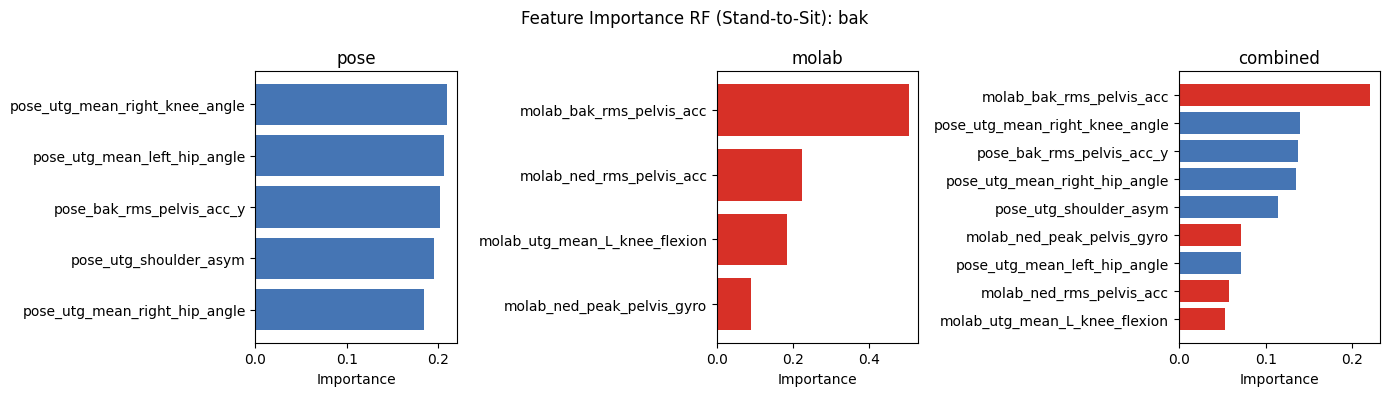

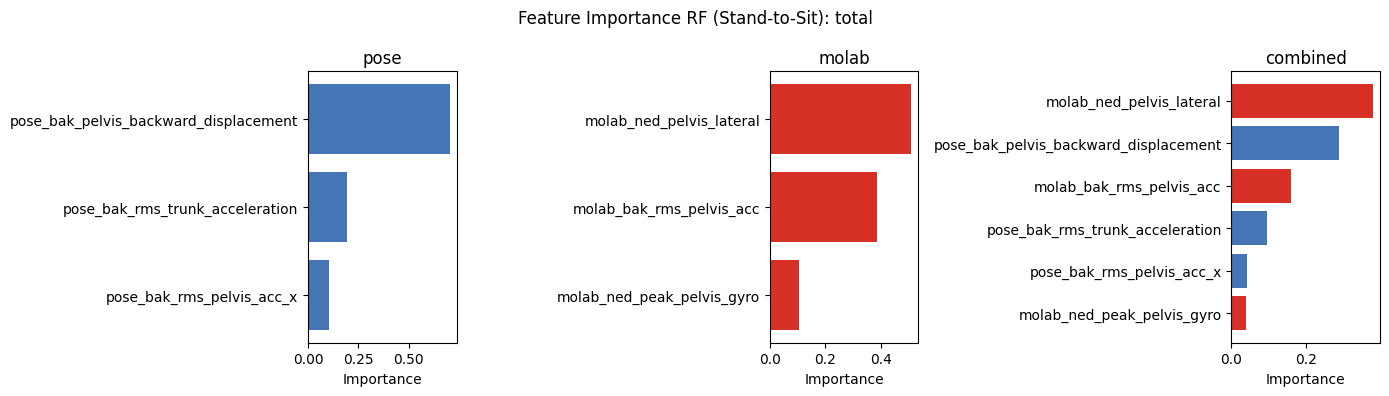

In [21]:
for phase in PHASE_ORDER_DOWN:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, fs in zip(axes, FEATURE_SETS):
        r = next(x for x in loocv_results_down
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        imp_df = pd.DataFrame({'feature': r['feature_names'], 'importance': r['mean_importances']})
        imp_df = imp_df.sort_values('importance')
        colors = ['#d73027' if 'molab_' in f else '#4575b4' for f in imp_df['feature']]
        ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
        ax.set_title(fs)
        ax.set_xlabel('Importance')
    fig.suptitle(f'Feature Importance RF (Stand-to-Sit): {phase}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN / f'feature_importance_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [22]:
videos_down = phase_dfs_down['utg']['y']['video'].tolist()

for phase in PHASE_ORDER_DOWN:
    pose_r  = next(r for r in loocv_results_down if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results_down if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    df = pd.DataFrame({
        'video':       videos_down,
        'pose_error':  np.abs(pose_r['y_true']  - pose_r['y_pred']),
        'molab_error': np.abs(molab_r['y_true'] - molab_r['y_pred']),
    })
    df['better'] = df.apply(lambda row: 'Pose' if row['pose_error'] < row['molab_error'] else 'MoLab', axis=1)

    print(f"\n{'='*60}\nPhase: {phase}\n{'='*60}")
    print(df.round(4).to_string(index=False))


Phase: utg
video  pose_error  molab_error better
  028      0.0432       0.0637   Pose
  030      0.7169       0.7051  MoLab
  045      0.6140       0.1601  MoLab
  047      0.0146       0.3373   Pose
  059      0.3918       0.2265  MoLab
  061      0.3013       0.0845  MoLab
  074      0.0116       0.0369   Pose
  076      0.6273       0.4142  MoLab
  091      0.1100       0.2852   Pose
  093      0.2088       0.5349   Pose

Phase: ned
video  pose_error  molab_error better
  028      0.1772       0.2318   Pose
  030      0.2734       0.1208  MoLab
  045      0.2287       0.0218  MoLab
  047      0.2485       0.1739  MoLab
  059      0.2344       0.0302  MoLab
  061      0.0117       0.2081   Pose
  074      0.0004       0.1536   Pose
  076      0.0010       0.0078   Pose
  091      0.0748       0.2299   Pose
  093      0.3757       0.3505  MoLab

Phase: bak
video  pose_error  molab_error better
  028      0.6217       0.7298   Pose
  030      0.6832       0.7356   Pose
  045      0.4

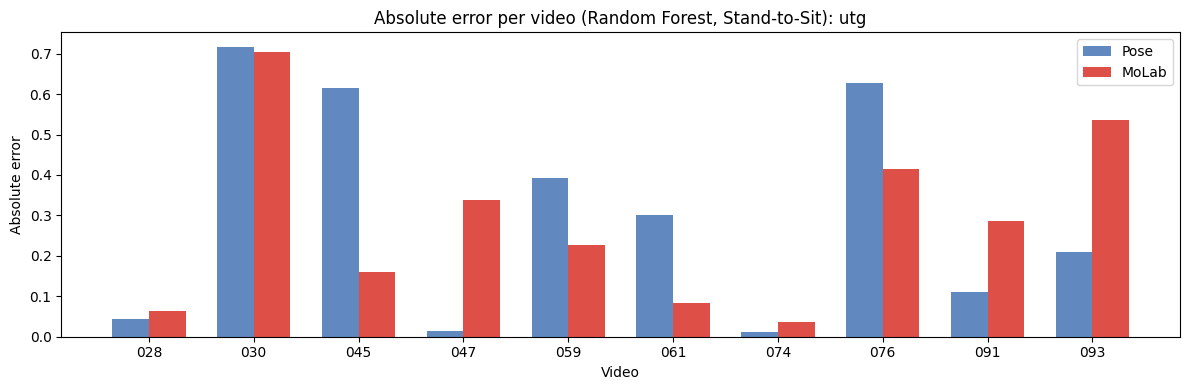

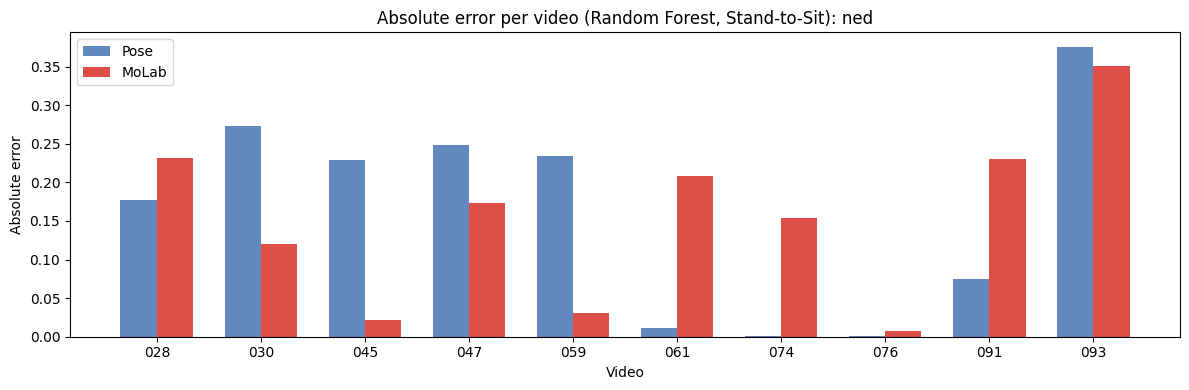

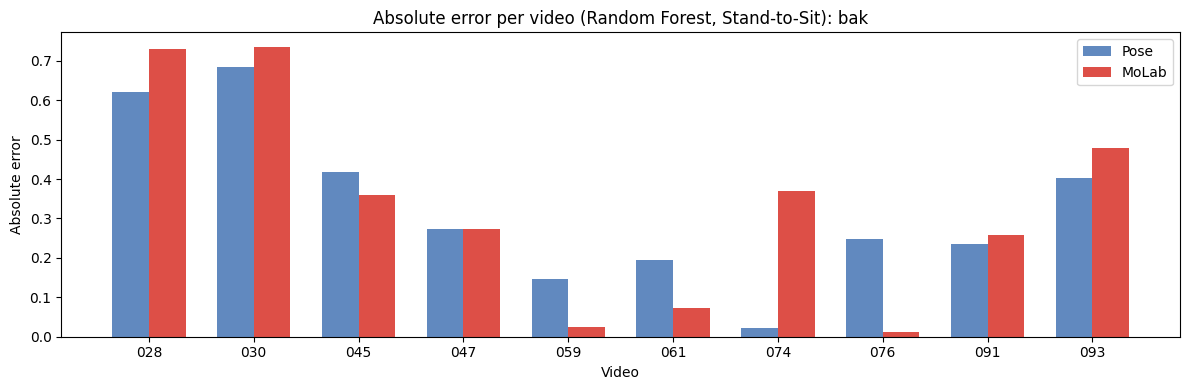

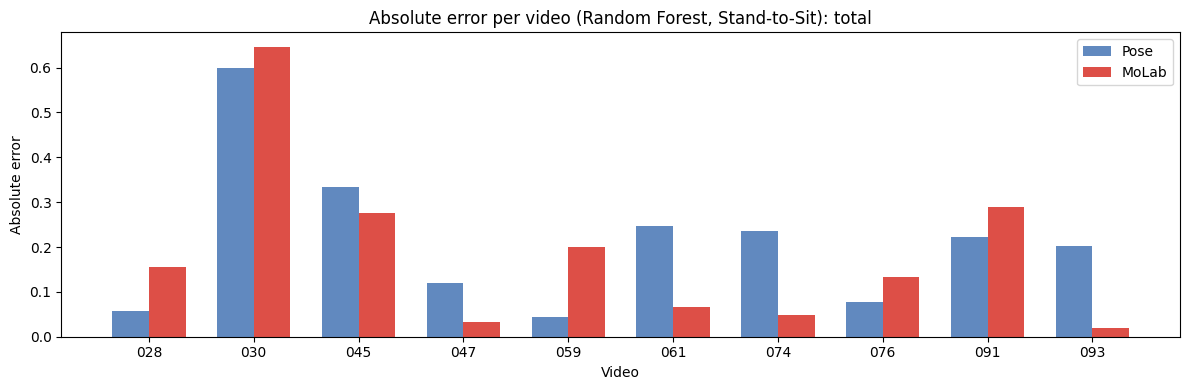

In [23]:
x_d = np.arange(len(videos_down))
width = 0.35

for phase in PHASE_ORDER_DOWN:
    pose_r  = next(r for r in loocv_results_down if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results_down if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    pose_errors  = np.abs(pose_r['y_true']  - pose_r['y_pred'])
    molab_errors = np.abs(molab_r['y_true'] - molab_r['y_pred'])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x_d - width/2, pose_errors,  width, label='Pose',  color='#4575b4', alpha=0.85)
    ax.bar(x_d + width/2, molab_errors, width, label='MoLab', color='#d73027', alpha=0.85)
    ax.set_title(f'Absolute error per video (Random Forest, Stand-to-Sit): {phase}')
    ax.set_xticks(x_d)
    ax.set_xticklabels(videos_down)
    ax.set_xlabel('Video')
    ax.set_ylabel('Absolute error')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN / f'error_analysis_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()
